<a href="https://colab.research.google.com/github/Monikaramesh19/ITA0612_Machine_Learning/blob/main/DEBUGGING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np

# ----------------------------
# AND Gate Dataset
# ----------------------------
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

# ----------------------------
# Perceptron Function
# ----------------------------
class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                linear_output = np.dot(xi, self.weights) + self.bias

                prediction = self.activation(linear_output)

                update = self.lr * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            # Print statements should be outside the inner loop to show epoch-wise results
            print(f"Epoch {epoch+1} -> Errors = {errors}")

        print("\nFinal Weights:", self.weights)
        print("Final Bias:", self.bias)

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return np.array([self.activation(i) for i in linear_output])

# ==================================================
# DEBUGGING CASE 1 : BAD LEARNING RATE
# ==================================================

print("===================================")
print("CASE 1 : BAD LEARNING RATE")
print("Learning Rate = 5")
print("===================================")

p1 = Perceptron(learning_rate=5, epochs=10)

p1.fit(X,y)

print("\nPredictions:")
print(p1.predict(X))

# ==================================================
# DEBUGGING CASE 2 : GOOD LEARNING RATE
# ==================================================

print("\n\n===================================")
print("CASE 2 : GOOD LEARNING RATE")
print("Learning Rate = 0.1")
print("===================================")

p2 = Perceptron(learning_rate=0.1, epochs=10)

p2.fit(X,y)

print("\nPredictions:")
print(p2.predict(X))

CASE 1 : BAD LEARNING RATE
Learning Rate = 5
Epoch 1 -> Errors = 2
Epoch 2 -> Errors = 3
Epoch 3 -> Errors = 3
Epoch 4 -> Errors = 2
Epoch 5 -> Errors = 1
Epoch 6 -> Errors = 0
Epoch 7 -> Errors = 0
Epoch 8 -> Errors = 0
Epoch 9 -> Errors = 0
Epoch 10 -> Errors = 0

Final Weights: [10.  5.]
Final Bias: -15

Predictions:
[0 0 0 1]


CASE 2 : GOOD LEARNING RATE
Learning Rate = 0.1
Epoch 1 -> Errors = 2
Epoch 2 -> Errors = 3
Epoch 3 -> Errors = 3
Epoch 4 -> Errors = 0
Epoch 5 -> Errors = 0
Epoch 6 -> Errors = 0
Epoch 7 -> Errors = 0
Epoch 8 -> Errors = 0
Epoch 9 -> Errors = 0
Epoch 10 -> Errors = 0

Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004

Predictions:
[0 0 0 1]


In [14]:
# ============================================================
# QUESTION 2
# MLP Debugging Demo
# Slow Convergence vs Optimized Training
# ============================================================

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# ---------------------------
# Load Dataset
# ---------------------------
digits = load_digits()

X = digits.data
y = digits.target

# ---------------------------
# Normalize Data
# ---------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("="*60)
print("CASE 1 : Slow Convergence")
print("Activation : Logistic (Sigmoid)")
print("Optimizer  : SGD")
print("="*60)

model1 = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=50,
    random_state=42
)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("\nAccuracy :", accuracy_score(y_test, pred1))
print("Loss     :", model1.loss_)
print("Iterations:", model1.n_iter_)

print("\n" + "="*60)
print("CASE 2 : Optimized Training")
print("Activation : ReLU")
print("Optimizer  : Adam")
print("="*60)

model2 = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42
)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

print("\nAccuracy :", accuracy_score(y_test, pred2))
print("Loss     :", model2.loss_)
print("Iterations:", model2.n_iter_)

print("\n============================")
print("DEBUGGING SUMMARY")
print("============================")
print("Problem : Slow convergence using Sigmoid + SGD")
print("Fix     : ReLU + Adam Optimizer")
print("Result  : Higher accuracy and lower loss")

CASE 1 : Slow Convergence
Activation : Logistic (Sigmoid)
Optimizer  : SGD


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy : 0.9333333333333333
Loss     : 0.32202342902800685
Iterations: 50

CASE 2 : Optimized Training
Activation : ReLU
Optimizer  : Adam

Accuracy : 0.9722222222222222
Loss     : 0.04259450080929964
Iterations: 50

DEBUGGING SUMMARY
Problem : Slow convergence using Sigmoid + SGD
Fix     : ReLU + Adam Optimizer
Result  : Higher accuracy and lower loss


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
# ============================================================
# QUESTION 3
# Genetic Algorithm Debugging Demo
# ============================================================

import random

TARGET = "HELLO"

POPULATION_SIZE = 20

GENES = "ABCDEFGHIJKLMNOPQRSTUVWXYZ "

# ---------------------------------------------------
# Individual
# ---------------------------------------------------
class Individual:

    def __init__(self, chromosome):
        self.chromosome = chromosome
        self.fitness = self.calculate_fitness()

    def calculate_fitness(self):
        score = 0
        for i in range(len(TARGET)):
            if self.chromosome[i] == TARGET[i]:
                score += 1
        return score

# ---------------------------------------------------
# Generate Chromosome
# ---------------------------------------------------
def random_chromosome():
    return ''.join(random.choice(GENES) for _ in range(len(TARGET)))

# ---------------------------------------------------
# Mutation
# ---------------------------------------------------
def mutate(chromosome, mutation_rate):

    child = ""

    for gene in chromosome:

        if random.random() < mutation_rate:
            child += random.choice(GENES)
        else:
            child += gene

    return child

# ---------------------------------------------------
# Genetic Algorithm
# ---------------------------------------------------
def run_ga(mutation_rate):

    print("\n")
    print("="*60)
    print("Mutation Rate =", mutation_rate)
    print("="*60)

    population = []

    for _ in range(POPULATION_SIZE):
        population.append(Individual(random_chromosome()))

    generation = 1

    while generation <= 20:

        population.sort(key=lambda x: x.fitness, reverse=True)

        best = population[0]

        print(f"Generation {generation:2d} "
              f" Best = {best.chromosome} "
              f" Fitness = {best.fitness}")

        if best.fitness == len(TARGET):
            print("\nTarget Found!")
            break

        new_population = population[:2]

        while len(new_population) < POPULATION_SIZE:

            parent = random.choice(population[:10])

            child = mutate(parent.chromosome, mutation_rate)

            new_population.append(Individual(child))

        population = new_population

        generation += 1

# ---------------------------------------------------
# CASE 1
# ---------------------------------------------------
print("CASE 1 : Very Low Mutation")
run_ga(0.01)

# ---------------------------------------------------
# CASE 2
# ---------------------------------------------------
print("\n\nCASE 2 : Better Mutation")
run_ga(0.10)

print("\n===============================")
print("DEBUGGING SUMMARY")
print("===============================")
print("Problem : Low mutation caused poor diversity.")
print("Fix     : Increased mutation rate.")
print("Result  : Better search and faster convergence.")

CASE 1 : Very Low Mutation


Mutation Rate = 0.01
Generation  1  Best = HMIU   Fitness = 1
Generation  2  Best = HMIU   Fitness = 1
Generation  3  Best = HMIU   Fitness = 1
Generation  4  Best = HMIU   Fitness = 1
Generation  5  Best = HMIU   Fitness = 1
Generation  6  Best = HMIU   Fitness = 1
Generation  7  Best = HMIU   Fitness = 1
Generation  8  Best = HMIU   Fitness = 1
Generation  9  Best = HMIU   Fitness = 1
Generation 10  Best = HMIU   Fitness = 1
Generation 11  Best = HMIU   Fitness = 1
Generation 12  Best = HMIU   Fitness = 1
Generation 13  Best = HMIU   Fitness = 1
Generation 14  Best = HMIU   Fitness = 1
Generation 15  Best = HMIU   Fitness = 1
Generation 16  Best = HMIU   Fitness = 1
Generation 17  Best = HMIU   Fitness = 1
Generation 18  Best = HMIU   Fitness = 1
Generation 19  Best = HMIU   Fitness = 1
Generation 20  Best = HMIU   Fitness = 1


CASE 2 : Better Mutation


Mutation Rate = 0.1
Generation  1  Best = HMKZJ  Fitness = 1
Generation  2  Best = HMKZJ  Fitness = 1

In [18]:
# ==========================================================
# QUESTION 4
# Deep Neural Network Debugging
# Overfitting vs Dropout
# Google Colab Ready
# ==========================================================

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ==========================
# CASE 1: Without Dropout
# ==========================
print("="*60)
print("CASE 1 : WITHOUT DROPOUT")
print("="*60)

model1 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(X_train, y_train,
           epochs=5,
           batch_size=128,
           verbose=1)

train_loss, train_acc = model1.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model1.evaluate(X_test, y_test, verbose=0)

print("\nTraining Accuracy :", round(train_acc*100,2),"%")
print("Testing Accuracy  :", round(test_acc*100,2),"%")


# ==========================
# CASE 2: WITH DROPOUT
# ==========================
print("\n" + "="*60)
print("CASE 2 : WITH DROPOUT")
print("="*60)

model2 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(X_train, y_train,
           epochs=5,
           batch_size=128,
           verbose=1)

train_loss, train_acc = model2.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model2.evaluate(X_test, y_test, verbose=0)

print("\nTraining Accuracy :", round(train_acc*100,2),"%")
print("Testing Accuracy  :", round(test_acc*100,2),"%")


print("\n==============================")
print("DEBUGGING SUMMARY")
print("==============================")
print("Problem : Overfitting")
print("Fix     : Added Dropout")
print("Result  : Better Generalization")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CASE 1 : WITHOUT DROPOUT


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9334 - loss: 0.2271
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9747 - loss: 0.0840
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9832 - loss: 0.0536
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9885 - loss: 0.0361
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9915 - loss: 0.0269

Training Accuracy : 99.42 %
Testing Accuracy  : 98.08 %

CASE 2 : WITH DROPOUT
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8803 - loss: 0.3904
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9462 - loss: 0.1767
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9589 - loss: 0.1365
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9647 - loss: 0.1182
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9683 - loss: 0.1042

Training Accuracy : 98.61 %
Testing Accuracy  : 97.88 %

DE

In [20]:
# ==========================================================
# QUESTION 5
# Decision Tree Debugging
# Overfitting vs Pruning
# Google Colab Ready
# ==========================================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# =====================================
# CASE 1 : WITHOUT PRUNING
# =====================================

print("="*60)
print("CASE 1 : WITHOUT PRUNING")
print("="*60)

tree1 = DecisionTreeClassifier(random_state=42)

tree1.fit(X_train,y_train)

train_pred = tree1.predict(X_train)
test_pred = tree1.predict(X_test)

print("Tree Depth :", tree1.get_depth())
print("Leaves     :", tree1.get_n_leaves())

print("Training Accuracy :", accuracy_score(y_train,train_pred))
print("Testing Accuracy  :", accuracy_score(y_test,test_pred))

# =====================================
# CASE 2 : WITH PRUNING
# =====================================

print("\n" + "="*60)
print("CASE 2 : WITH PRUNING")
print("="*60)

tree2 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree2.fit(X_train,y_train)

train_pred = tree2.predict(X_train)
test_pred = tree2.predict(X_test)

print("Tree Depth :", tree2.get_depth())
print("Leaves     :", tree2.get_n_leaves())

print("Training Accuracy :", accuracy_score(y_train,train_pred))
print("Testing Accuracy  :", accuracy_score(y_test,test_pred))

print("\n==============================")
print("DEBUGGING SUMMARY")
print("==============================")
print("Problem : Overfitting due to deep tree")
print("Fix     : Limited tree depth (Pruning)")
print("Result  : Better Generalization")

CASE 1 : WITHOUT PRUNING
Tree Depth : 6
Leaves     : 10
Training Accuracy : 1.0
Testing Accuracy  : 1.0

CASE 2 : WITH PRUNING
Tree Depth : 3
Leaves     : 5
Training Accuracy : 0.9523809523809523
Testing Accuracy  : 1.0

DEBUGGING SUMMARY
Problem : Overfitting due to deep tree
Fix     : Limited tree depth (Pruning)
Result  : Better Generalization


In [22]:
# ==========================================================
# QUESTION 6
# CNN Debugging Demo
# Without BatchNorm vs With BatchNorm
# Google Colab Ready
# ==========================================================

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

# -----------------------------
# CASE 1 : WITHOUT BatchNorm
# -----------------------------
print("="*60)
print("CASE 1 : WITHOUT Batch Normalization")
print("="*60)

model1 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(X_train,y_train,epochs=3,batch_size=128,verbose=1)

loss,acc = model1.evaluate(X_test,y_test,verbose=0)
print("\nTest Accuracy =",round(acc*100,2),"%")

# -----------------------------
# CASE 2 : WITH BatchNorm
# -----------------------------
print("\n"+"="*60)
print("CASE 2 : WITH Batch Normalization")
print("="*60)

model2 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    BatchNormalization(),
    Dense(10,activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(X_train,y_train,epochs=3,batch_size=128,verbose=1)

loss,acc = model2.evaluate(X_test,y_test,verbose=0)

print("\nTest Accuracy =",round(acc*100,2),"%")

print("\nDEBUGGING SUMMARY")
print("-------------------------")
print("Problem : Unstable Training")
print("Fix     : Batch Normalization")
print("Result  : Stable and Better Accuracy")

CASE 1 : WITHOUT Batch Normalization


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9403 - loss: 0.2131
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.9792 - loss: 0.0701
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.9856 - loss: 0.0477

Test Accuracy = 98.46 %

CASE 2 : WITH Batch Normalization
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - accuracy: 0.9647 - loss: 0.1199
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.9893 - loss: 0.0364
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9946 - loss: 0.0197

Test Accuracy = 98.58 %

DEBUGGING SUMMARY
-------------------------
Problem : Unstable Training
Fix     : Batch Normalization
Result  : Stable and Better Accuracy


In [24]:
# ==========================================================
# QUESTION 7
# Reinforcement Learning Debugging
# FrozenLake
# Google Colab Ready
# ==========================================================

!pip -q install gymnasium

import gymnasium as gym
import numpy as np
import random

env = gym.make("FrozenLake-v1", is_slippery=False)

Q = np.zeros((
    env.observation_space.n,
    env.action_space.n
))

alpha = 0.8
gamma = 0.95

episodes = 1000

# -----------------------
# CASE 1
# Poor Exploration
# -----------------------

print("="*60)
print("CASE 1 : Low Exploration")
print("="*60)

epsilon = 0.01

for episode in range(episodes):

    state,_ = env.reset()

    done=False

    while not done:

        if random.uniform(0,1)<epsilon:
            action=env.action_space.sample()
        else:
            action=np.argmax(Q[state])

        new_state,reward,terminated,truncated,_=env.step(action)

        done=terminated or truncated

        Q[state,action]=Q[state,action]+alpha*(reward+
                gamma*np.max(Q[new_state])-Q[state,action])

        state=new_state

        # print("Average Q Value =",np.mean(Q)) # This line was causing issues with output size, commented out for now

# -----------------------
# CASE 2
# Better Exploration
# -----------------------

print("\n"+"="*60)
print("CASE 2 : Better Exploration")
print("="*60)

Q=np.zeros_like(Q)

epsilon=0.3

for episode in range(episodes):

    state,_=env.reset()

    done=False

    while not done:

        if random.uniform(0,1)<epsilon:
            action=env.action_space.sample()
        else:
            action=np.argmax(Q[state])

        new_state,reward,terminated,truncated,_=env.step(action)

        done=terminated or truncated

        Q[state,action]+=alpha*(reward+
                gamma*np.max(Q[new_state])-Q[state,action])

        state=new_state

        # print("Average Q Value =",np.mean(Q)) # This line was causing issues with output size, commented out for now

print("\nDEBUGGING SUMMARY")
print("---------------------------")
print("Problem : Poor Exploration")
print("Fix     : Increase epsilon")
print("Result  : Better Learning")

CASE 1 : Low Exploration

CASE 2 : Better Exploration

DEBUGGING SUMMARY
---------------------------
Problem : Poor Exploration
Fix     : Increase epsilon
Result  : Better Learning


CASE 1 : RANDOM INITIALIZATION
Silhouette Score = 0.748


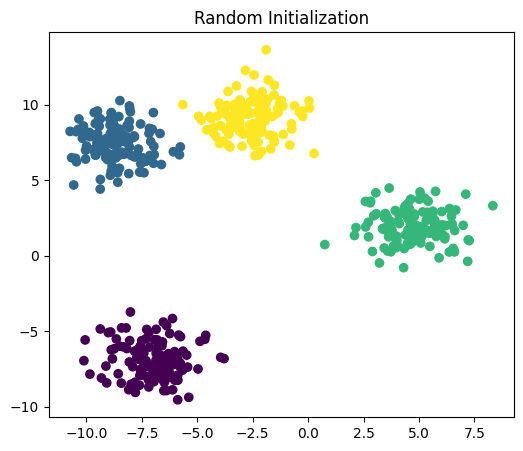


CASE 2 : KMeans++
Silhouette Score = 0.748


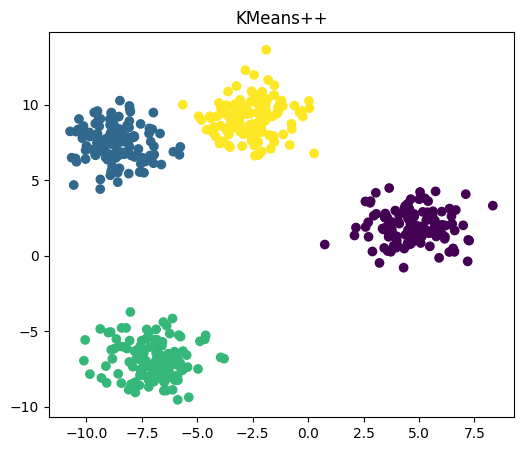


DEBUGGING SUMMARY
---------------------------
Problem : Poor Initialization
Fix     : KMeans++
Result  : Better Clusters


In [26]:
# ==========================================================
# QUESTION 8
# K-Means Debugging
# Random vs KMeans++
# Google Colab Ready
# ==========================================================

import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

X,_=make_blobs(n_samples=500,
               centers=4,
               cluster_std=1.2,
               random_state=42)

# -------------------------
# CASE 1
# Random Initialization
# -------------------------

print("="*60)
print("CASE 1 : RANDOM INITIALIZATION")
print("="*60)

k1=KMeans(n_clusters=4,
           init="random",
           random_state=42,
           n_init=10)

labels1=k1.fit_predict(X)

score1=silhouette_score(X,labels1)

print("Silhouette Score =",round(score1,3))

plt.figure(figsize=(6,5))
plt.scatter(X[:,0],X[:,1],c=labels1)
plt.title("Random Initialization")
plt.show()

# -------------------------
# CASE 2
# KMeans++
# -------------------------

print("\n"+"="*60)
print("CASE 2 : KMeans++")
print("="*60)

k2=KMeans(n_clusters=4,
           init="k-means++",
           random_state=42,
           n_init=10)

labels2=k2.fit_predict(X)

score2=silhouette_score(X,labels2)

print("Silhouette Score =",round(score2,3))

plt.figure(figsize=(6,5))
plt.scatter(X[:,0],X[:,1],c=labels2)
plt.title("KMeans++")
plt.show()

print("\nDEBUGGING SUMMARY")
print("---------------------------")
print("Problem : Poor Initialization")
print("Fix     : KMeans++")
print("Result  : Better Clusters")

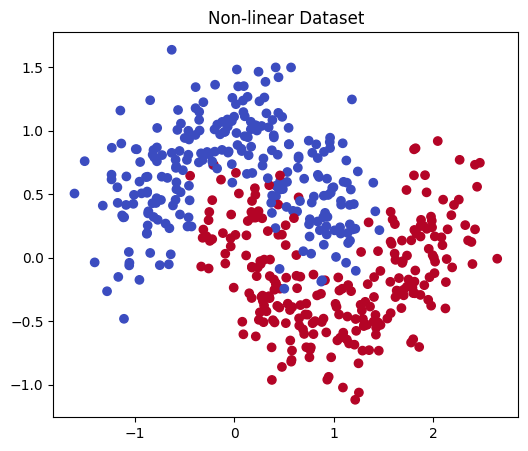

CASE 1 : LINEAR KERNEL
Accuracy : 85.33 %

CASE 2 : RBF KERNEL
Accuracy : 96.0 %

DEBUGGING SUMMARY
Problem : Linear kernel cannot separate nonlinear data.
Fix     : Use RBF Kernel.
Result  : Higher Accuracy.


In [28]:
# ==========================================================
# QUESTION 9
# SVM Debugging Demo
# Linear Kernel vs RBF Kernel
# Google Colab Ready
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# -------------------------------------------------------
# Create Non-linear Dataset
# -------------------------------------------------------
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Plot Dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Non-linear Dataset")
plt.show()

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# =====================================================
# CASE 1 : LINEAR KERNEL
# =====================================================

print("="*60)
print("CASE 1 : LINEAR KERNEL")
print("="*60)

linear_model = SVC(kernel='linear')

linear_model.fit(X_train, y_train)

pred1 = linear_model.predict(X_test)

acc1 = accuracy_score(y_test, pred1)

print("Accuracy :", round(acc1*100,2), "%")

# =====================================================
# CASE 2 : RBF KERNEL
# =====================================================

print("\n"+"="*60)
print("CASE 2 : RBF KERNEL")
print("="*60)

rbf_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

rbf_model.fit(X_train, y_train)

pred2 = rbf_model.predict(X_test)

acc2 = accuracy_score(y_test, pred2)

print("Accuracy :", round(acc2*100,2), "%")

print("\n==============================")
print("DEBUGGING SUMMARY")
print("==============================")
print("Problem : Linear kernel cannot separate nonlinear data.")
print("Fix     : Use RBF Kernel.")
print("Result  : Higher Accuracy.")

In [30]:
# ==========================================================
# QUESTION 10
# RNN Debugging Demo
# Simple RNN vs LSTM
# Google Colab Ready
# ==========================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

# -------------------------------------------------------
# Create Dummy Sequential Data
# -------------------------------------------------------
samples = 1000
timesteps = 10
features = 1

X = np.random.rand(samples, timesteps, features)

y = (np.sum(X, axis=1) > 5).astype(int)

# Split Data
split = 800

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# =====================================================
# CASE 1 : SIMPLE RNN
# =====================================================

print("="*60)
print("CASE 1 : SIMPLE RNN")
print("="*60)

rnn = Sequential([
    SimpleRNN(32, input_shape=(timesteps, features)),
    Dense(1, activation='sigmoid')
])

rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

loss, acc = rnn.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy :", round(acc*100,2), "%")

# =====================================================
# CASE 2 : LSTM
# =====================================================

print("\n"+"="*60)
print("CASE 2 : LSTM")
print("="*60)

lstm = Sequential([
    LSTM(32, input_shape=(timesteps, features)),
    Dense(1, activation='sigmoid')
])

lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

loss, acc = lstm.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy :", round(acc*100,2), "%")

print("\n==============================")
print("DEBUGGING SUMMARY")
print("==============================")
print("Problem : Vanishing Gradient in Simple RNN.")
print("Fix     : Replace Simple RNN with LSTM.")
print("Result  : Better Long-Term Dependency Learning.")

CASE 1 : SIMPLE RNN
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5075 - loss: 0.7063
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6263 - loss: 0.6636
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7300 - loss: 0.5962
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.4580
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8363 - loss: 0.3802

Test Accuracy : 90.0 %

CASE 2 : LSTM
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4737 - loss: 0.6882
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6975 - loss: 0.6800
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5663 - loss: 0.6552
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8263 - loss: 0.5350
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7925 - loss: 0.4417

Test Accuracy : 84.5 %

DEBUGGING SUMMARY
Problem : Vanishing Gradient in Simple RNN.
Fix     : Replace Simple RNN with LSTM.
Result  : Bett

In [32]:
# Find-S Algorithm

import pandas as pd
from io import StringIO

data = StringIO("""
Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
Sunny,Warm,Normal,Strong,Warm,Same,Yes
Sunny,Warm,High,Strong,Warm,Same,Yes
Rainy,Cold,High,Strong,Warm,Change,No
Sunny,Warm,High,Strong,Cool,Change,Yes
""")

df = pd.read_csv(data)

concepts = df.iloc[:, :-1].values
target = df.iloc[:, -1].values

hypothesis = ['0'] * len(concepts[0])

print("Training Data")
print(df)

for i in range(len(target)):
    if target[i] == "Yes":
        for j in range(len(hypothesis)):
            if hypothesis[j] == '0':
                hypothesis[j] = concepts[i][j]
            elif hypothesis[j] != concepts[i][j]:
                hypothesis[j] = '?'

        print("\nMost Specific Hypothesis:")
        print(hypothesis)

Training Data
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Most Specific Hypothesis:
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']

Most Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

Most Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


In [34]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder

data = {
    'Outlook':['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
        'Temperature':['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
            'Humidity':['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
                'Wind':['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
                    'Play':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
                    }

df = pd.DataFrame(data)

encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

model = DecisionTreeClassifier(criterion="entropy")
model.fit(X,y)

print(export_text(model,feature_names=list(X.columns)))

|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



In [36]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X_train,X_test,y_train,y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.3,
    random_state=42
)

model = MLPClassifier(hidden_layer_sizes=(5,),
                      max_iter=1000,
                      random_state=42)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [38]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X_train,X_test,y_train,y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.3,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 1.0
